In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [106]:
df = pd.read_csv("/content/bank-full.csv", sep=";")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (45211, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [107]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [108]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [109]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [110]:
df.duplicated().sum()

np.int64(0)

In [111]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


In [112]:
df["y"].value_counts(normalize=True) * 100

,proportion
y,
no,88.30152
yes,11.69848


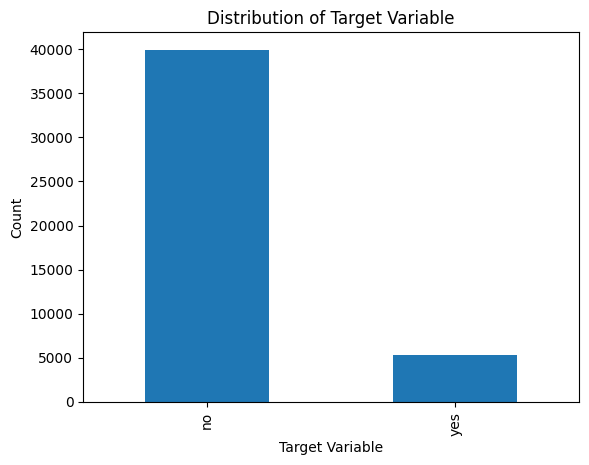

In [113]:
df['y'].value_counts().plot(kind='bar')
plt.title('Distribution of Target Variable')
plt.xlabel('Target Variable')
plt.ylabel('Count')
plt.show()

In [114]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:

    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- job ---
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
Name: count, dtype: int64

--- marital ---
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

--- education ---
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

--- default ---
default
no     44396
yes      815
Name: count, dtype: int64

--- housing ---
housing
yes    25130
no     20081
Name: count, dtype: int64

--- loan ---
loan
no     37967
yes     7244
Name: count, dtype: int64

--- contact ---
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

--- month ---
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
Name: count, dtyp

In [115]:
X = df.drop('y', axis=1)
y = df['y']

In [116]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget:")
print(y.value_counts())

X shape: (45211, 16)
y shape: (45211,)

Target:
y
no     39922
yes     5289
Name: count, dtype: int64


In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

In [118]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target:")
print(y_test.value_counts(normalize=True) * 100)

Training data: (36168, 16)
Testing data: (9043, 16)

Training target:
y
no     88.301814
yes    11.698186
Name: proportion, dtype: float64

Testing target:
y
no     88.300343
yes    11.699657
Name: proportion, dtype: float64


In [119]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:")
print(cat_cols)

print("\nNumerical columns:")
print(num_cols)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [120]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

## Logistic Regression

In [121]:
logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))


])

In [122]:
logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [123]:
y_pred = logreg_pipeline.predict(X_test)

In [124]:
print(y_pred[:20])

['no' 'no' 'no' 'no' 'no' 'no' 'no' 'yes' 'no' 'no' 'no' 'no' 'no' 'no'
 'no' 'no' 'no' 'no' 'no' 'no']


In [125]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.901249585314608

Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7985
         yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



## Random Forest

In [126]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200,random_state=42, n_jobs=1))
    ])

In [127]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=1,
                                        random_state=42))])

In [128]:
rf_pred = rf_model.predict(X_test)

In [129]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9061152272475949

Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7985
         yes       0.66      0.40      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.72      9043
weighted avg       0.89      0.91      0.90      9043



## XGBoost

In [130]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ]
)

In [131]:
# Map target variables to numeric labels for XGBoost
y_train_encoded = y_train.map({'no': 0, 'yes': 1})
y_test_encoded = y_test.map({'no': 0, 'yes': 1})

# Fit the XGBoost pipeline
xgb_model.fit(X_train, y_train_encoded)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callback...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [132]:
xgb_pred = xgb_model.predict(X_test)

In [133]:
xgb_accuracy = accuracy_score(y_test_encoded, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

print("\nClassification Report:")
print(classification_report(y_test_encoded, xgb_pred))

XGBoost Accuracy: 0.9106491208669689

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.66      0.49      0.56      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.73      0.76      9043
weighted avg       0.90      0.91      0.90      9043



Confusion Matrix:
[[7719  266]
 [ 542  516]]


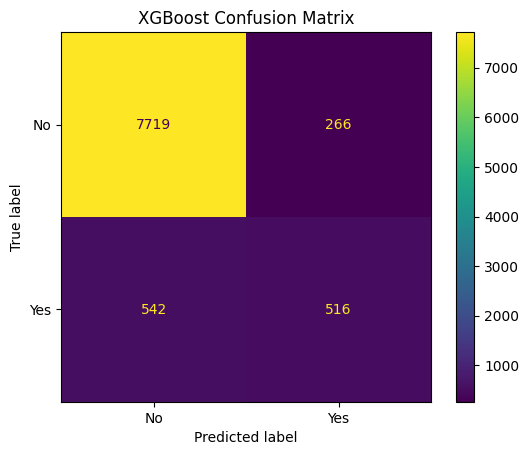

In [134]:
cm = confusion_matrix(y_test_encoded, xgb_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

In [135]:
# Probability of "yes"
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, xgb_proba)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9348653488996973
